# iEMG vs sEMG

Using the sEMG -> we test the performance

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import scipy, os
from sklearn.metrics import confusion_matrix
import seaborn as sns

import sys

from sklearn.model_selection import learning_curve

sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
import baseline, config, Model, utils, Same_with_MATLAB, Feature_info, shared_iENG_sEMG

import warnings
warnings.filterwarnings('ignore')


In [3]:
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
H = []

### 방금 Manual하게 feature extraction 을 써봤는데 그냥 원래 저장되어 있는 mat['Data_Fea'] 보다 한참 안좋음 - 코드에 문제 있는듯

(34487, 4, 14, 1) (34487,)
(8613, 4, 14, 1) (8613,)
Start Training (total epochs: 100)...
Maximum training accuracy : 89.97%
Maximum validation accuracy : 88.6%


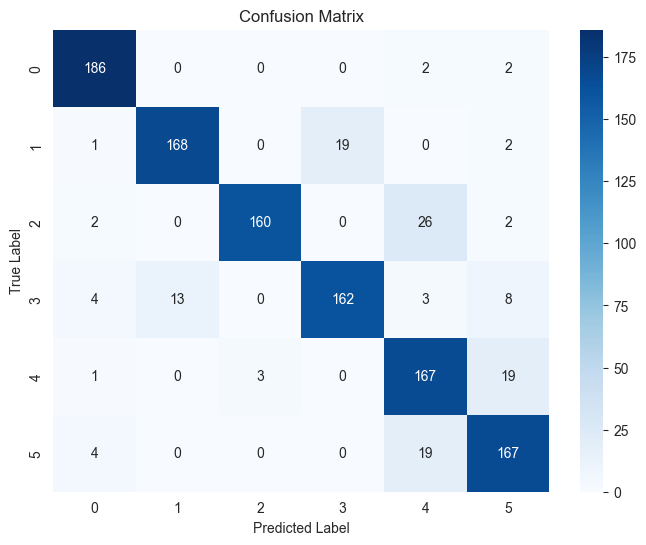

In [5]:
H_CM = shared_iENG_sEMG.run(subject='Byeongchan', Train_session=[0,1,2,3], Test_session=[4])
H.append(H_CM)
# Adam lr 0.1 = Maximum validation accuracy : 76%
# Adam lr 0.05 = Maximum validation accuracy : 77.94%
# Adam lr 0.01 = Maximum validation accuracy : 88.5%
# Adam lr 0.005 = Maximum validation accuracy : 88.6%
# Adam lr 0.001 = Maximum validation accuracy : 82.34%

(34475, 4, 14, 1) (34475,)
(8625, 4, 14, 1) (8625,)
Start Training (total epochs: 100)...
Maximum training accuracy : 90.65%
Maximum validation accuracy : 92.05%


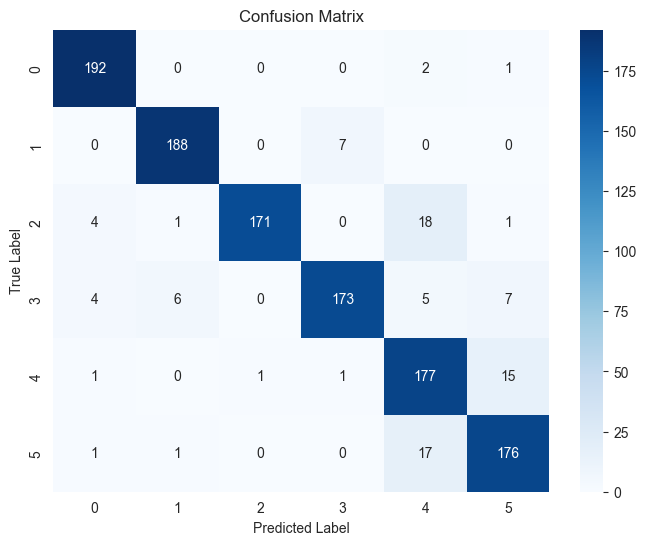

In [6]:
H_CM = shared_iENG_sEMG.run(subject='Byeongchan', Train_session=[0,1,2,4], Test_session=[3])
H.append(H_CM)

(34475, 4, 14, 1) (34475,)
(8625, 4, 14, 1) (8625,)
Start Training (total epochs: 100)...
Maximum training accuracy : 89.59%
Maximum validation accuracy : 88.41%


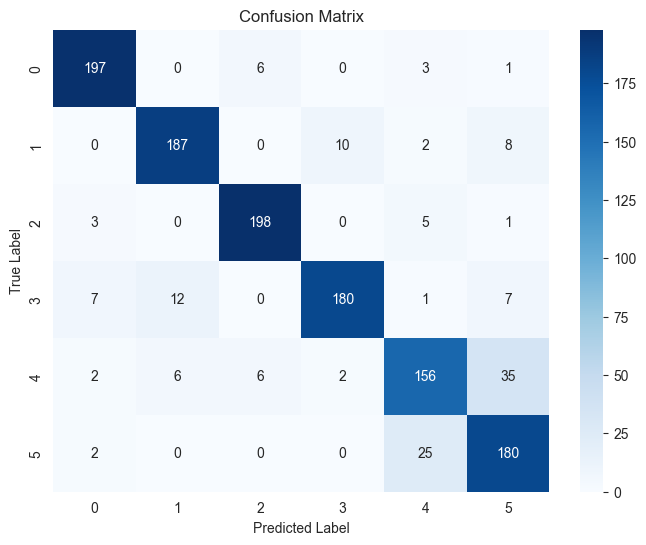

In [7]:
H_CM = shared_iENG_sEMG.run(subject='Byeongchan', Train_session=[0,1,3,4], Test_session=[2])
H.append(H_CM)

(34484, 4, 14, 1) (34484,)
(8616, 4, 14, 1) (8616,)
Start Training (total epochs: 100)...
Maximum training accuracy : 90.02%
Maximum validation accuracy : 90.82%


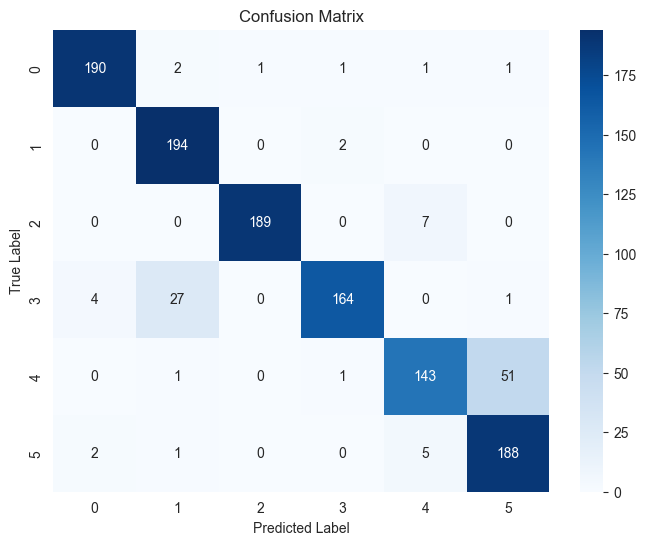

In [8]:
H_CM = shared_iENG_sEMG.run(subject='Byeongchan', Train_session=[0,2,3,4], Test_session=[1])
H.append(H_CM)

(34479, 4, 14, 1) (34479,)
(8621, 4, 14, 1) (8621,)
Start Training (total epochs: 100)...
Maximum training accuracy : 91.31%
Maximum validation accuracy : 88.74%


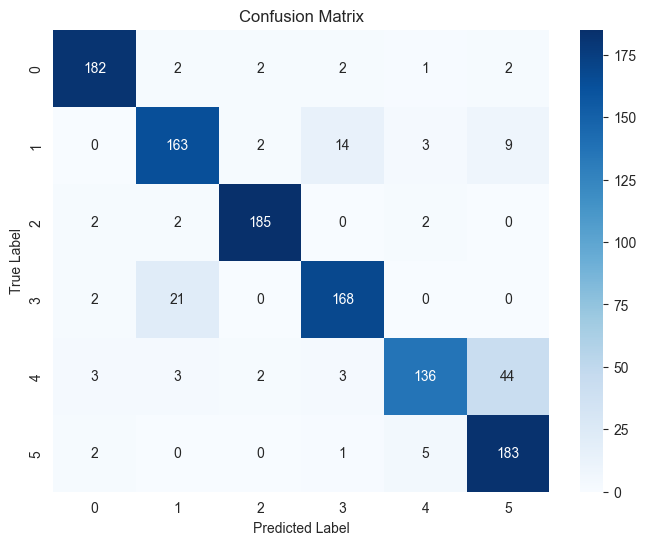

In [9]:
H_CM = shared_iENG_sEMG.run(subject='Byeongchan', Train_session=[1,2,3,4], Test_session=[0])
H.append(H_CM)

In [10]:
np.mean(H, axis=0)

array([[189.4,   0.8,   1.8,   0.6,   1.8,   1.4],
       [  0.2, 180. ,   0.4,  10.4,   1. ,   3.8],
       [  2.2,   0.6, 180.6,   0. ,  11.6,   0.8],
       [  4.2,  15.8,   0. , 169.4,   1.8,   4.6],
       [  1.4,   2. ,   2.4,   1.4, 155.8,  32.8],
       [  2.2,   0.4,   0. ,   0.2,  14.2, 178.8]])

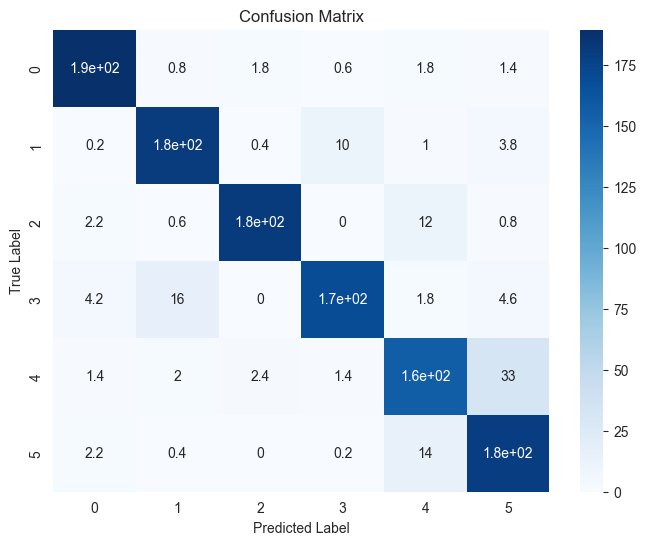

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(np.mean(H, axis=0), annot=True, cmap='Blues', xticklabels=range(6), yticklabels=range(6))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [12]:
pd.DataFrame(np.mean(H, axis=0)).to_csv('results/subject_BY_cross_validation_result_sENG-6class.csv', index=False)

# Conclusion

sENG - 성능 잘나옴: 2D CNN 썼을때 (모든 feature 사용시) 약 77~91% in intersession

내일 병찬이랑 민정이 데이터 collection해서 실험돌리기

# Analysis - gesture 별로만 비교 해야할듯
- collection 부위도 다르고 amputee라서 애매함
- 근데 제스쳐 자체는 같았으니 feature로 해도될듯